### Conditional Workflow

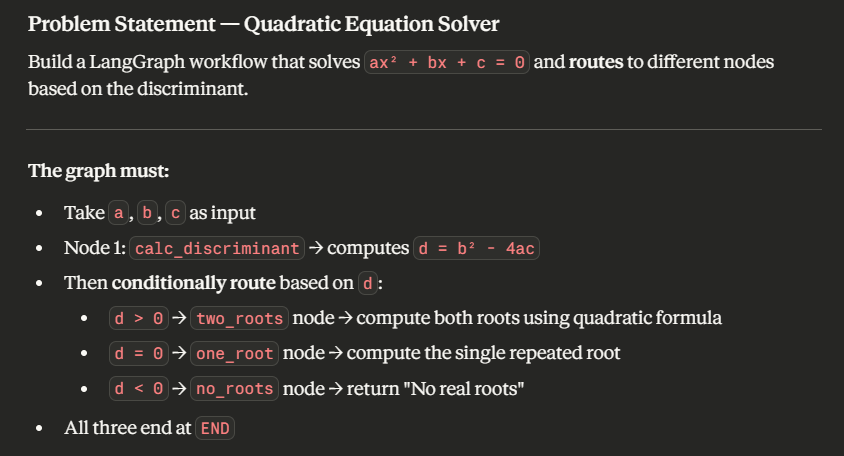

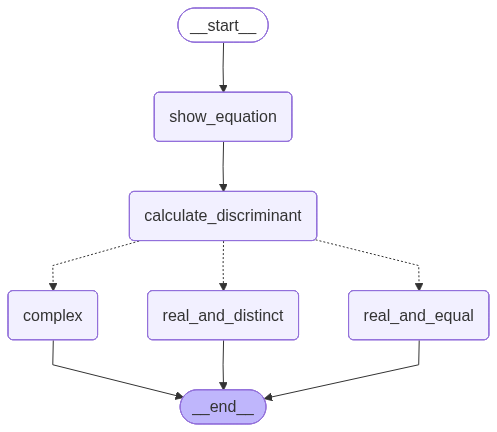

In [14]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

class QuadraticState(TypedDict):
    a: int
    b: int
    c: int
    equation: str
    discriminant: float
    results: str

graph = StateGraph(QuadraticState)

def show_equation(state: QuadraticState) -> str:
    a = state["a"]
    b = state["b"]
    c = state["c"]
    equation = f"{a}x^2 + {b}x + {c} = 0"
    return {"equation": equation}

def calculate_discriminant(state: QuadraticState) -> float:
    a = state["a"]
    b = state["b"]
    c = state["c"]
    discriminant = b**2 - 4*a*c
    return {"discriminant": discriminant}

def real_and_distinct(state: QuadraticState):
    root1 = (-state["b"] + state["discriminant"]**0.5) / (2*state["a"])
    root2 = (-state["b"] - state["discriminant"]**0.5) / (2*state["a"])
    return {"results": f"Real and Distinct roots: {root1} and {root2}"}

def real_and_equal(state: QuadraticState):
    root = -state["b"] / (2*state["a"])
    return {"results": f"Real and Equal root: {root}"}

def complex(state: QuadraticState):
    real_part = -state["b"] / (2*state["a"])
    imaginary_part = (abs(state["discriminant"])**0.5) / (2*state["a"])
    return {"results": f"Complex roots: {real_part} ± {imaginary_part}i"}
    
#####################################
# conditional workflow function
#####################################
def determine_root_type(state: QuadraticState) -> Literal["real_and_distinct", "real_and_equal", "complex"]:
    if state["discriminant"] > 0:
        return "real_and_distinct"
    elif state["discriminant"] == 0:
        return "real_and_equal"
    else:
        return "complex"


graph.add_node("show_equation", show_equation)
graph.add_node("calculate_discriminant", calculate_discriminant)
graph.add_node("real_and_distinct", real_and_distinct)
graph.add_node("real_and_equal", real_and_equal)
graph.add_node("complex", complex)

graph.add_edge(START, "show_equation")
graph.add_edge("show_equation", "calculate_discriminant")
graph.add_conditional_edges("calculate_discriminant", determine_root_type)
graph.add_edge("real_and_distinct", END)
graph.add_edge("real_and_equal", END)
graph.add_edge("complex", END)

workflow = graph.compile()

from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [15]:
initial_state = {
    "a": 4,
    "b": -5,
    "c": -4
}

workflow.invoke(initial_state)

{'a': 4,
 'b': -5,
 'c': -4,
 'equation': '4x^2 + -5x + -4 = 0',
 'discriminant': 89,
 'results': 'Real and Distinct roots: 1.8042476415070754 and -0.5542476415070754'}

#### Practice 

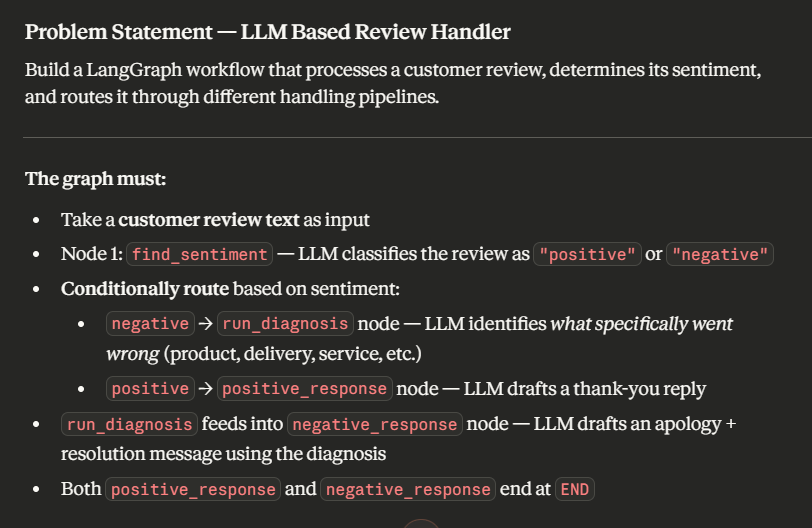